---
title: "deepSSF Example Script"
author:
  - name: Scott Forrest
    url: https://swforrest.github.io/
    orcid: 0000-0001-9529-0108
    affiliation: Queensland University of Technology, CSIRO
    email: "scottwforrest@gmail.com"
date: today
format:
    html:
        toc: true
        number_sections: true
        code-fold: show
        code-tools: true
        code-overflow: scroll
        # embed-resources: true
        css: ../styles.css
# bibliography: references.bib
abstract: |
  Here we show an example of how to use the functions in the deepSSF package, showing data loading, model training and testing and generating simulations.

  We use data that comes with the package in the **datasets** folder, which is the GPS tracking data of a single water buffalo (~10,000 locations), and two spatial layers, NDVI (the average from 2018-2019, which covers the temporal extent of the data), and slope.
---

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import rasterio

import deepssf
from deepssf import (
    ConvJointModel,
    EarlyStopping,
    ModelParams,
    create_gif,
    fit,
    get_device,
    load_environmental_layers,
    make_dataloaders,
    make_optimisers,
    negativeLogLikeLoss,
    filter_steps_by_window,
    prepare_movement_df,
    simulate_trajectory,
    validate_next_step_probs,
)

import pandas as pd
from datetime import datetime                # Date/time utilities
from IPython.display import Image            # For plotting GIFs
from rasterio.plot import show               # For plotting raster layers

print(f"deepssf {deepssf.__version__}")
print(f"torch {torch.__version__}")

deepssf 0.1.2
torch 2.12.0


In [2]:
# Reproducibility — fix random seeds so results are the same on every run.
torch.manual_seed(42)
np.random.seed(42)

# DEVICE is capitalised because it is a module-level constant (set once, never reassigned).
# get_device() returns 'cuda' if a GPU is available, 'mps' on Apple Silicon,
# or 'cpu' otherwise.  All tensors and the model are moved to this device.
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


# Import data

The csv file is imported with a timestamp and an x and y coordinate. In our case the data was already in a projected format that is specific to Australia (EPSG:3112)

In [3]:
# All-caps names below are module-level constants — set once here and referenced
# throughout the notebook without being reassigned.  Python has no built-in
# constant keyword, so capitalisation is the community convention (PEP 8) to
# signal "do not change this value".

DATA_DIR = Path("../src/deepssf/datasets/data")  # location of the bundled sample data
CSV_PATH = DATA_DIR / "buffalo_djelk_id2005.csv"  # GPS tracking data for individual 2005
LAYER_PATHS = {
    "ndvi":  str(DATA_DIR / "ndvi_2005.tif"),   # Normalised Difference Vegetation Index
    "slope": str(DATA_DIR / "slope_2005.tif"),  # terrain slope derived from a DEM
}
OUTPUT_DIR   = Path("outputs")                    # figures and model checkpoints go here
SNAPSHOT_DIR = OUTPUT_DIR / "training_snapshots"  # per-batch prediction-map snapshots
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
raw_df = pd.read_csv(CSV_PATH)
print(f"Raw GPS fixes : {len(raw_df):,}")
print(f"Individuals   : {raw_df['id'].nunique()}")

# Sort by the individual ID and timestamp to ensure correct temporal order
raw_df = raw_df.sort_values(by=["id", "time"]).reset_index(drop=True)

# # Convert the 'time' column to the correct timezone (here Australia/Darwin) 
# raw_df["time"] = (
#         pd.to_datetime(raw_df["time"], utc=True)
#         .dt.tz_convert("Australia/Darwin")
#     )

raw_df.head()

Raw GPS fixes : 10,297
Individuals   : 1


,id,time,x,y
0,2005,2018-07-25T00:04:02Z,41941.331695,-1.435875e+06
1,2005,2018-07-25T01:04:23Z,41969.310875,-1.435671e+06
2,2005,2018-07-25T02:04:39Z,41921.521939,-1.435654e+06
3,2005,2018-07-25T03:04:17Z,41779.439594,-1.435601e+06
4,2005,2018-07-25T04:04:39Z,41841.203272,-1.435635e+06


In [5]:
# load_environmental_layers() reads each GeoTIFF listed in LAYER_PATHS, min–max
# scales every band to [0, 1], and returns:
#   env_layers       — dict mapping layer name → 2-D NumPy array (H × W)
#   raster_transform — Affine object that converts pixel (row, col) indices to
#                      projected coordinates (easting, northing) in the same CRS
#                      as the GPS data.  This transform is used whenever we need
#                      to translate between pixel space and real-world coordinates.
env_layers, raster_transform = load_environmental_layers(LAYER_PATHS)
print("Layers loaded:", list(env_layers.keys()))
for name, arr in env_layers.items():
    print(f"  {name}: shape={arr.shape}, min={arr.min():.3f}, max={arr.max():.3f}")

Layer 'ndvi': min=-0.06614641100168228, max=0.731696367263794 → scaled to [0, 1]
Layer 'slope': min=0.00013558653881773353, max=12.298083305358887 → scaled to [0, 1]
Layers loaded: ['ndvi', 'slope']
  ndvi: shape=(758, 1175), min=0.000, max=1.090
  slope: shape=(758, 1175), min=0.000, max=1.000


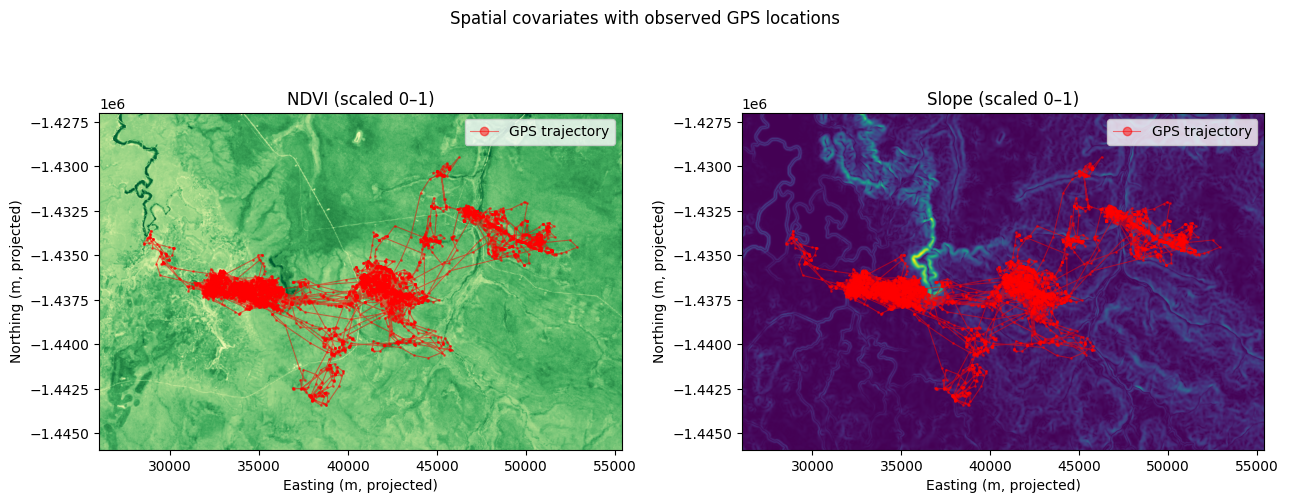

In [6]:
# Plot each spatial covariate with the observed GPS locations overlaid.
# This confirms the raster extent covers the animal's home range and gives
# a visual sense of the landscape the model will learn from.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

layer_meta = [
    ("ndvi",  "NDVI (scaled 0–1)",  "YlGn"),
    ("slope", "Slope (scaled 0–1)", "viridis"),
]

for ax, (name, label, cmap) in zip(axes, layer_meta):
    rasterio.plot.show(env_layers[name], transform=raster_transform, ax=ax, cmap=cmap)
    ax.plot(
        raw_df["x"], raw_df["y"],
        "r-o", alpha=0.5, markersize=1, linewidth=0.8, label="GPS trajectory",
    )
    ax.set_xlabel("Easting (m, projected)")
    ax.set_ylabel("Northing (m, projected)")
    ax.set_title(label)
    ax.legend(loc="upper right", markerscale=6)

plt.suptitle("Spatial covariates with observed GPS locations", y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "spatial_covariates.png"), dpi=100)
plt.show()

In [7]:
# prepare_movement_df() converts a fixes dataframe (one row per GPS location)
# into a *step* dataframe (one row per movement between consecutive fixes).
# For each step it computes:
#   dx, dy          — displacement in projected CRS units (metres)
#   bearing         — direction of travel (radians; 0 = north, clockwise positive)
#   bearing_tm1     — bearing of the *previous* step, used as a model input so
#                     the network can capture directional persistence (autocorrelation)
#   dt_hour         — time elapsed between consecutive fixes (hours)
#   hour_t1, yday_t1— decimal hour-of-day and day-of-year at the step start location
#   *_sin1 / *_cos1 — sine/cosine encodings of hour and yday (see SCALAR_COLS below)
# The trailing underscore on column names (x1_, y1_, t1_, etc.) flags them as
# "start of step" variables; x2_, y2_, t2_ are the corresponding "end of step" values.
# The last fix for each individual is dropped because no forward step can be formed.
step_df = prepare_movement_df(raw_df)
print(f"Movement steps : {len(step_df):,}  ({len(raw_df) - len(step_df)} dropped — last fix per individual)")
step_df.head()

Movement steps : 10,296  (1 dropped — last fix per individual)


,id,t1_,x1_,y1_,t2_,x2_,y2_,dx,dy,bearing,bearing_tm1,dt_hour,hour_t1,yday_t1,hour_t1_sin1,hour_t1_cos1,yday_t1_sin1,yday_t1_cos1
0,2005,2018-07-25T00:04:02Z,41941.331695,-1.435875e+06,2018-07-25T01:04:23Z,41969.310875,-1.435671e+06,27.979180,204.064135,1.434536,0.000000,1.005833,0.066667,206.0,0.017452,0.999848,-0.391358,-0.920239
1,2005,2018-07-25T01:04:23Z,41969.310875,-1.435671e+06,2018-07-25T02:04:39Z,41921.521939,-1.435654e+06,-47.788936,16.857110,2.802478,1.434536,1.004444,1.066667,206.0,0.275637,0.961262,-0.391358,-0.920239
2,2005,2018-07-25T02:04:39Z,41921.521939,-1.435654e+06,2018-07-25T03:04:17Z,41779.439594,-1.435601e+06,-142.082345,53.568427,2.781049,2.802478,0.993889,2.066667,206.0,0.515038,0.857167,-0.391358,-0.920239
3,2005,2018-07-25T03:04:17Z,41779.439594,-1.435601e+06,2018-07-25T04:04:39Z,41841.203272,-1.435635e+06,61.763677,-34.322938,-0.507220,2.781049,1.006111,3.066667,206.0,0.719340,0.694658,-0.391358,-0.920239
4,2005,2018-07-25T04:04:39Z,41841.203272,-1.435635e+06,2018-07-25T05:04:27Z,41655.463332,-1.435604e+06,-185.739939,31.003534,2.976198,-0.507220,0.996667,4.066667,206.0,0.874620,0.484810,-0.391358,-0.920239


In [8]:
# ---------------------------------------------------------------------------
# SCALAR_COLS — non-spatial inputs that are broadcast into the spatial window
# ---------------------------------------------------------------------------
# The model receives a fixed-size spatial window centred on each step's start
# location.  To let the network express time-varying habitat preferences (e.g.
# different nocturnal vs diurnal use), scalar covariates are tiled into
# additional channels of the same H × W size, so every pixel "knows" the
# current time context when habitat suitability is estimated.
#
#   hour_t1_sin1 / hour_t1_cos1
#       Sine and cosine of (2π × hour / 24), encoding time-of-day as a
#       *circular* variable.  The circular encoding means 23:00 and 01:00 are
#       treated as adjacent — a plain hour value would have an artificial
#       discontinuity at midnight.
#
#   yday_t1_sin1 / yday_t1_cos1
#       Same circular encoding for day-of-year (1–365), capturing seasonal
#       variation in habitat use (e.g. dry-season vs wet-season movements).
#
#   dt_hour
#       Elapsed time between consecutive fixes (hours).  Because GPS collars
#       do not always fix at a perfectly regular rate, including dt_hour lets
#       the movement kernel rescale expected displacement proportionally to
#       the actual time interval rather than assuming a fixed fix rate.
#       Note: dt_hour must be supplied at *simulation* time as well, so that
#       simulate_trajectory() produces inputs consistent with training.
# ---------------------------------------------------------------------------
SCALAR_COLS = ["hour_t1_sin1", "hour_t1_cos1", "yday_t1_sin1", "yday_t1_cos1", "dt_hour"]

WINDOW_SIZE = 101   # spatial context window side length (pixels); 101 × 25 m = 2525 m radius
PIXEL_SIZE  = 25    # raster resolution in metres — must match the loaded GeoTIFFs
BATCH_SIZE  = 32    # number of steps per training mini-batch

# ---------------------------------------------------------------------------
# Pre-calculate the flattened CNN output size so ModelParams can be set
# without hard-coding it.  The formula mirrors the layers inside ConvJointModel:
#   conv (padding=1) keeps the spatial dimension unchanged at each layer
#   maxpool k=2, s=2 halves the spatial dimension (floor division) at each layer
# ---------------------------------------------------------------------------
OUTPUT_CHANNELS = 4
dim = WINDOW_SIZE
for _ in range(3):
    dim = math.floor((dim + 2 * 1 - 3) / 1 + 1)  # conv (pad=1 preserves dim)
    dim = math.floor((dim - 2) / 2 + 1)           # maxpool k=2, s=2
DENSE_DIM = OUTPUT_CHANNELS * dim * dim
print(f"After 3× conv+maxpool: dim={dim}  →  dense_dim_in_all={DENSE_DIM}")

# filter_steps_by_window() removes steps whose straight-line displacement
# exceeds half the spatial window (WINDOW_SIZE × PIXEL_SIZE / 2 metres).
# Such steps would place the true next location outside the predicted
# probability map, causing an index error in the loss function.
step_df = filter_steps_by_window(step_df, window_size=WINDOW_SIZE, pixel_size=PIXEL_SIZE)
print(f"Steps after window filter: {len(step_df):,}")

After 3× conv+maxpool: dim=12  →  dense_dim_in_all=576
Steps after window filter: 10,101


In [9]:
# make_dataloaders() splits step_df chronologically into train / val / test
# subsets (here 80 / 10 / 10 %) and returns a PyTorch DataLoader for each.
# Each DataLoader yields tuples of:
#   x1  — spatial window tensor  (batch × n_spatial_channels × H × W)
#          One channel per entry in LAYER_PATHS, cropped around each step's start pixel.
#   x2  — scalar covariate tensor (batch × len(SCALAR_COLS))
#          Raw scalar values; broadcast into spatial maps *inside* the model.
#   x3  — previous bearing tensor (batch × 1)
#          Conditions the movement kernel on the direction of the prior step.
#   (px2, py2) — pixel indices of the *true* next location within the window
#          Used by the loss function to look up the predicted probability at the
#          observed destination.
# The layer_paths argument causes the function to re-read the rasters internally,
# so the DataLoader is independent of the env_layers dict loaded above.
dl_train, dl_val, dl_test = make_dataloaders(
    layer_paths=LAYER_PATHS,
    window_size=WINDOW_SIZE,
    batch_size=BATCH_SIZE,
    train_split=0.8,
    val_split=0.1,
    scalar_cols=SCALAR_COLS,
    df=step_df,
)
print(f"Train batches : {len(dl_train)}")
print(f"Val   batches : {len(dl_val)}")
print(f"Test  batches : {len(dl_test)}")

Layer 'ndvi': min=-0.06614641100168228, max=0.731696367263794 → scaled to [0, 1]
Layer 'slope': min=0.00013558653881773353, max=12.298083305358887 → scaled to [0, 1]
Train batches : 253
Val   batches : 32
Test  batches : 32


/Users/scottforrest/Library/Mobile Documents/com~apple~CloudDocs/github_repos/deepSSF_package/src/deepssf/data.py:366: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.scalar_to_grid_data = torch.from_numpy(


In [10]:
# Inspect one batch to verify tensor shapes match ModelParams expectations.
# x1 has one channel per spatial layer (ndvi + slope = 2).  The scalar covariates
# in x2 are broadcast to full H × W maps *inside* ConvJointModel and concatenated
# with x1 there, giving the CNN 2 + len(SCALAR_COLS) = 7 input channels total.
x1, x2, x3, (px2, py2), _ = next(iter(dl_train))
print(f"Spatial   x1 : {x1.shape}   (batch × channels × H × W)")
print(f"Scalars   x2 : {x2.shape}   (batch × len(SCALAR_COLS))")
print(f"Bearing   x3 : {x3.shape}   (batch × 1)")
print(f"Next-step px2: {px2[:4].tolist()}  py2: {py2[:4].tolist()}")

Spatial   x1 : torch.Size([32, 2, 101, 101])   (batch × channels × H × W)
Scalars   x2 : torch.Size([32, 5])   (batch × len(SCALAR_COLS))
Bearing   x3 : torch.Size([32, 1])   (batch × 1)
Next-step px2: [54, 51, 50, 50]  py2: [51, 53, 50, 50]


In [11]:
# Inspect one batch
x1, x2, x3, (px2, py2), _ = next(iter(dl_train))
print(f"Spatial   x1 : {x1.shape}   (batch × channels × H × W)")
print(f"Scalars   x2 : {x2.shape}")
print(f"Bearing   x3 : {x3.shape}")
print(f"Next-step px2: {px2[:4].tolist()}  py2: {py2[:4].tolist()}")

Spatial   x1 : torch.Size([32, 2, 101, 101])   (batch × channels × H × W)
Scalars   x2 : torch.Size([32, 5])
Bearing   x3 : torch.Size([32, 1])
Next-step px2: [50, 52, 60, 40]  py2: [50, 61, 58, 59]


In [12]:
# ModelParams is a thin dict-like container that groups all architecture
# hyper-parameters so they can be passed to ConvJointModel and logged together.
params = ModelParams({
    "batch_size":                BATCH_SIZE,
    "image_dim":                 WINDOW_SIZE,           # spatial window side length (pixels)
    "pixel_size":                PIXEL_SIZE,            # metres per pixel
    "dim_in_nonspatial_to_grid": len(SCALAR_COLS),      # scalar channels tiled into the window
    "dense_dim_in_nonspatial":   len(SCALAR_COLS),      # scalar inputs to the dense MLP branch
    "dense_dim_hidden":          64,                    # hidden units in the scalar MLP
    "dense_dim_in_all":          DENSE_DIM,             # flattened CNN output size (computed above)
    "input_channels":            2 + len(SCALAR_COLS),  # 2 env layers + scalar-to-grid channels
    "output_channels":           OUTPUT_CHANNELS,       # feature maps out of each conv layer
    "kernel_size":               3,                     # conv kernel spatial size
    "stride":                    1,
    "kernel_size_mp":            2,                     # max-pool kernel size
    "stride_mp":                 2,
    "padding":                   1,                     # same-padding to preserve spatial dims through conv
    "num_movement_params":       12,                    # parameters of the movement kernel
    "dropout":                   0.0,
    "device":                    DEVICE,
})

# ConvJointModel is a joint habitat–movement model with two heads:
#   1. Habitat head — a small CNN applied to the spatial window (env layers + tiled
#      scalars) that outputs a per-pixel log-suitability map.
#   2. Movement head — a dense MLP that takes the scalar covariates and the previous
#      bearing, and produces parameters for a parametric movement kernel (a mixture
#      of wrapped distributions centred on the current location).
# The two log-probability surfaces are summed pixel-wise to give the joint
# predicted probability map for the animal's next step.
model = ConvJointModel(params).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")

Model parameters : 43,009


In [13]:
# negativeLogLikeLoss scores each predicted probability map against the true
# next-step pixel index; minimising it pushes probability mass toward observed locations.
loss_fn = negativeLogLikeLoss(reduction="mean")

# make_optimisers() creates two Adam optimisers with separate learning rates:
#   lr_habitat   — controls the CNN (habitat) head; typically higher
#   lr_movement  — controls the movement-kernel MLP; kept lower for stability
# It also returns a ReduceLROnPlateau scheduler for each optimiser that reduces
# the learning rate by a factor of 'scheduler_factor' (default = 0.1) if validation 
# loss does not improve for 'scheduler_patience' epochs (default = 5).
optimisers, schedulers = make_optimisers(
    model, lr_habitat=1e-4, lr_movement=1e-5, scheduler_patience=3, scheduler_factor=0.1
)

# EarlyStopping monitors validation loss and saves the best model weights to disk
# whenever a new minimum is reached.  Training stops automatically if the loss
# does not improve for `patience` consecutive epochs, preventing overfitting.
early_stop = EarlyStopping(
    patience=5, verbose=True, path=str(OUTPUT_DIR / "best_model.pt")
)

In [14]:
# fit() runs the full training loop.
#   Inputs : model, train/val dataloaders, loss function, optimisers,
#            learning-rate schedulers, early-stopping callback, and snapshot settings.
#   Outputs: history dict with keys 'train_losses' and 'val_losses'
#            (one scalar value per completed epoch).
# Every snapshot_item training steps, a predicted probability map is written to
# SNAPSHOT_DIR.  create_gif() (next cell) assembles these into an animation so
# you can see how the predictions evolve as training progresses.
#
# image_trim_pixels tells fit() how many outer pixel rings to trim from the CNN output
# before scoring.  Each conv+pool stage reduces the effective receptive field near
# the image boundary, so trimming avoids penalising predictions in regions where
# the network has only seen zero-padded input. 
history = fit(
    model=model,
    image_trim_pixels=4,
    window_size=WINDOW_SIZE,
    dl_train=dl_train,
    dl_val=dl_val,
    loss_fn=loss_fn,
    optimisers=optimisers,
    schedulers=schedulers,
    n_epochs=50,
    early_stopping=early_stop,
    snapshot_dir=str(SNAPSHOT_DIR),
    snapshot_item=500,
)


Epoch 1/50
loss:        6.369064  [   32/ 8081]
loss:        5.908315  [  352/ 8081]
loss:        6.511573  [  672/ 8081]
loss:        5.800290  [  992/ 8081]
loss:        6.319576  [ 1312/ 8081]
loss:        6.483375  [ 1632/ 8081]
loss:        5.740562  [ 1952/ 8081]
loss:        6.611397  [ 2272/ 8081]
loss:        6.797694  [ 2592/ 8081]
loss:        5.995838  [ 2912/ 8081]
loss:        6.464476  [ 3232/ 8081]
loss:        6.720701  [ 3552/ 8081]
loss:        6.599788  [ 3872/ 8081]
loss:        6.732468  [ 4192/ 8081]
loss:        6.807412  [ 4512/ 8081]
loss:        5.985386  [ 4832/ 8081]
loss:        6.867531  [ 5152/ 8081]
loss:        6.155656  [ 5472/ 8081]
loss:        6.512724  [ 5792/ 8081]
loss:        6.435010  [ 6112/ 8081]
loss:        6.080071  [ 6432/ 8081]
loss:        5.949783  [ 6752/ 8081]
loss:        7.075795  [ 7072/ 8081]
loss:        5.844541  [ 7392/ 8081]
loss:        6.322108  [ 7712/ 8081]
loss:        6.032080  [ 8032/ 8081]

Avg training loss:       

Animation saved: outputs/training_progress.gif
Training GIF → outputs/training_progress.gif


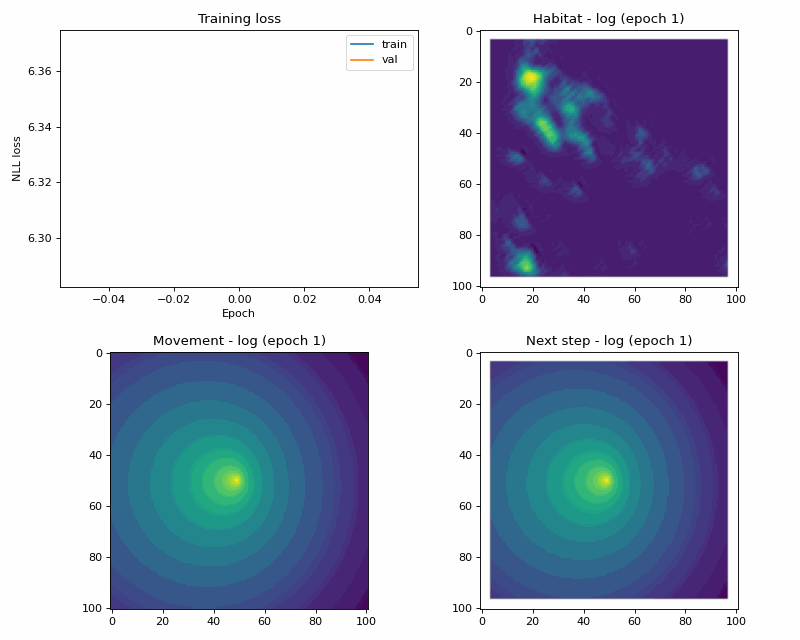

In [23]:
gif_path = str(OUTPUT_DIR / "training_progress.gif")
create_gif(str(SNAPSHOT_DIR), gif_path, fps=5)
print(f"Training GIF → {gif_path}")

# Play the gif
Image(gif_path)

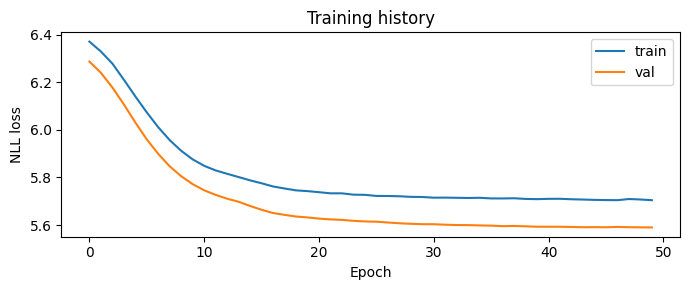

In [24]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["train_losses"], label="train")
ax.plot(history["val_losses"],   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("NLL loss")
ax.legend()
ax.set_title("Training history")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "loss_history.png"), dpi=100)
plt.show()

## 4  Validate against withheld test data

In [25]:
# Convert the NumPy rasters loaded earlier into PyTorch tensors.
# Both validate_next_step_probs() and simulate_trajectory() call
# get_landscape(month_index) at each step to fetch the current environmental
# layers as a list of 2-D tensors.
# With static (non-seasonal) rasters the month_index argument is unused.
# For seasonal data (e.g. monthly NDVI composites) you would index into a
# stack of layers here based on the current month.
ndvi_t  = torch.from_numpy(env_layers["ndvi"].astype(np.float32))
slope_t = torch.from_numpy(env_layers["slope"].astype(np.float32))

def get_landscape(_month_index):
    # Returns layers in the same order as LAYER_PATHS.
    return [ndvi_t, slope_t]

In [26]:
# Use the last 10 % of steps as the test set (matches the DataLoader split).
n_test      = int(len(step_df) * 0.1)
test_sample = step_df.iloc[-n_test:].reset_index(drop=True)
print(f"Validating on {len(test_sample):,} steps")

# validate_next_step_probs() runs the model forward on each test step and
# records the probability mass assigned to the *true* next location.
#   Inputs : model, test dataframe, landscape callable, raster Affine transform,
#            window size, scalar column names, temporal column names,
#            and a function mapping day-of-year → month index (for get_landscape).
#   Outputs: test_sample dataframe with three new columns appended:
#     habitat_prob   — probability at the true location from the habitat head alone
#     move_prob      — probability at the true location from the movement head alone
#     next_step_prob — joint (habitat × movement) probability at the true location
# Higher values mean the model correctly concentrated probability mass near the
# observed next fix.  The distribution of next_step_prob over many steps is the
# primary validation metric.
val_results = validate_next_step_probs(
    model,
    test_sample,
    get_landscape=get_landscape,
    transform=raster_transform,
    window_size=WINDOW_SIZE,
    scalar_cols=tuple(SCALAR_COLS),
    yday_col="yday_t1",
    bearing_col="bearing_tm1",
    month_index_fn=lambda _yday: 0,   # static layers — month doesn't matter
)
print(val_results[["habitat_prob", "move_prob", "next_step_prob"]].describe())

Validating on 1,010 steps
       habitat_prob    move_prob  next_step_prob
count   1010.000000  1010.000000     1010.000000
mean       0.000105     0.030598        0.031351
std        0.000042     0.083803        0.084849
min        0.000000     0.000000        0.000000
25%        0.000090     0.000238        0.000254
50%        0.000094     0.005471        0.005831
75%        0.000107     0.019572        0.020045
max        0.000347     0.522100        0.521275


In [27]:
# Use the last 10 % of steps as the test set (matches the DataLoader split)
n_test      = int(len(step_df) * 0.1)
test_sample = step_df.iloc[-n_test:].reset_index(drop=True)
print(f"Validating on {len(test_sample):,} steps")

val_results = validate_next_step_probs(
    model,
    test_sample,
    get_landscape=get_landscape,
    transform=raster_transform,
    window_size=WINDOW_SIZE,
    scalar_cols=tuple(SCALAR_COLS),
    yday_col="yday_t1",
    bearing_col="bearing_tm1",
    month_index_fn=lambda _yday: 0,   # static layers — month doesn't matter
)
print(val_results[["habitat_prob", "move_prob", "next_step_prob"]].describe())

Validating on 1,010 steps
       habitat_prob    move_prob  next_step_prob
count   1010.000000  1010.000000     1010.000000
mean       0.000105     0.030598        0.031351
std        0.000042     0.083803        0.084849
min        0.000000     0.000000        0.000000
25%        0.000090     0.000238        0.000254
50%        0.000094     0.005471        0.005831
75%        0.000107     0.019572        0.020045
max        0.000347     0.522100        0.521275


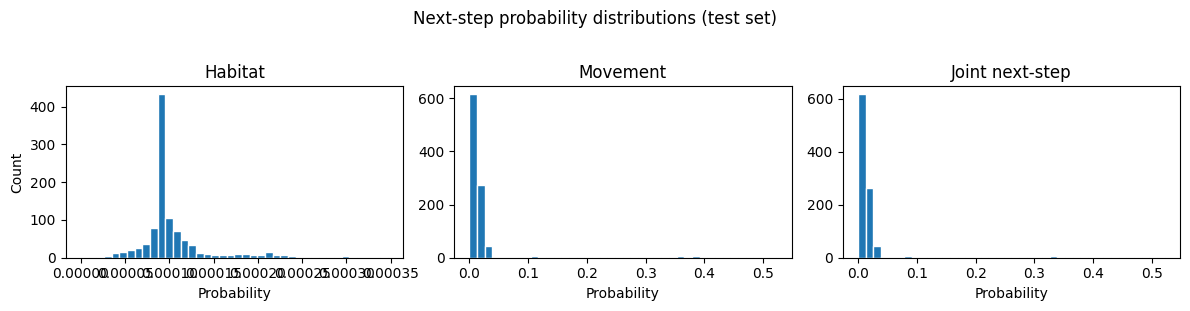

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col, title in zip(
    axes,
    ["habitat_prob", "move_prob", "next_step_prob"],
    ["Habitat", "Movement", "Joint next-step"],
):
    data = val_results[col].dropna()
    ax.hist(data, bins=40, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Probability")
axes[0].set_ylabel("Count")
plt.suptitle("Next-step probability distributions (test set)", y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "validation_probs.png"), dpi=100)
plt.show()

# Start the simulation near the centre of the observed home range.
start_x = float(step_df["x1_"].median())
start_y = float(step_df["y1_"].median())
print(f"Starting location: ({start_x:.0f}, {start_y:.0f})")

# simulate_trajectory() generates a sequence of steps by iteratively:
#   1. Extracting a spatial window centred on the current location.
#   2. Running the model to obtain a joint log-probability surface over that window.
#   3. Sampling the next pixel from that surface (softmax-normalised probabilities).
#   4. Converting the sampled pixel back to projected coordinates and advancing time.
#
#   Inputs : model, landscape callable, raster Affine transform, starting (x, y),
#            number of steps, starting day-of-year and hour-of-day, time between
#            steps in hours, window size, and a month-index function.
#   Outputs: DataFrame with one row per simulated step containing:
#     x, y           — projected coordinates of the simulated location
#     hour, yday     — time variables updated at each step
#     hab_log_prob   — full habitat log-probability surface (H × W list) for that step
#     move_log_prob  — full movement log-probability surface
#     step_log_prob  — joint log-probability surface (sum of the above)
sim_df = simulate_trajectory(
    model,
    get_landscape=get_landscape,
    transform=raster_transform,
    start_x=start_x,
    start_y=start_y,
    n_steps=1000,
    starting_yday=test_sample["yday_t1"].iloc[0],
    starting_hour=test_sample["hour_t1"].iloc[0],
    time_between_steps=1.0,
    window_size=WINDOW_SIZE,
    month_index_fn=lambda _yday: 0,   # static layers
)
print(f"Simulated {len(sim_df)} steps")
sim_df.head()

In [35]:
start_x = float(step_df["x1_"].median())
start_y = float(step_df["y1_"].median())
print(f"Starting location: ({start_x:.0f}, {start_y:.0f})")

sim_df = simulate_trajectory(
    model,
    get_landscape=get_landscape,
    transform=raster_transform,
    start_x=start_x,
    start_y=start_y,
    n_steps=1000,
    starting_yday=test_sample["yday_t1"].iloc[0],
    starting_hour=test_sample["hour_t1"].iloc[0],
    time_between_steps=1.0,
    window_size=WINDOW_SIZE,
    month_index_fn=lambda _yday: 0,   # static layers
)
print(f"Simulated {len(sim_df)} steps")
sim_df.head()

Starting location: (36111, -1436905)
Simulated 1000 steps


,x,y,hour,yday,month_index,hab_log_prob,move_log_prob,step_log_prob
0,35938.668020,-1.436533e+06,18.916667,255.000000,0,"[[-7.8557806, -8.091846, -8.266459, -8.336579,...","[[-15.034596, -14.980559, -14.926839, -14.8734...","[[-22.890377, -23.072407, -23.193298, -23.2100..."
1,35936.460924,-1.436535e+06,19.916667,255.041667,0,"[[-7.8606834, -8.089105, -8.2545185, -8.304174...","[[-14.4672, -14.415128, -14.363442, -14.312161...","[[-22.327885, -22.504232, -22.617962, -22.6163..."
2,35887.295436,-1.436538e+06,20.916667,255.083333,0,"[[-8.253597, -8.45499, -8.611316, -8.6401615, ...","[[-14.677285, -14.627965, -14.579047, -14.5305...","[[-22.930882, -23.082954, -23.190363, -23.1707..."
3,35894.628361,-1.436534e+06,21.916667,255.125000,0,"[[-8.782425, -8.924642, -9.044293, -9.050753, ...","[[-14.312975, -14.264019, -14.215485, -14.1673...","[[-23.0954, -23.18866, -23.259777, -23.21814, ..."
4,35867.165302,-1.436538e+06,22.916667,255.166667,0,"[[-9.067888, -9.124618, -9.180861, -9.147677, ...","[[-14.384404, -14.330968, -14.277831, -14.2250...","[[-23.452293, -23.455585, -23.458693, -23.3726..."


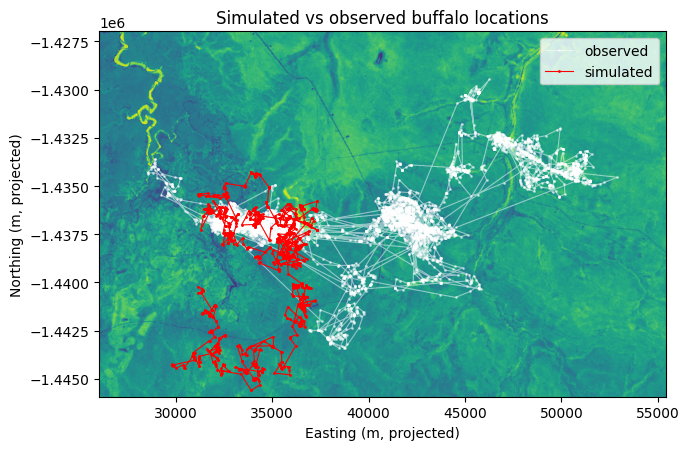

In [36]:
fig, ax = plt.subplots(figsize=(7, 6))
rasterio.plot.show(env_layers["ndvi"], transform=raster_transform, ax=ax, cmap='viridis')
ax.plot(
    step_df["x1_"], step_df["y1_"],
    "w-o", alpha=0.5, markersize=1, linewidth=0.8, label="observed",
)
ax.plot(
    sim_df["x"], sim_df["y"],
    "r-o", markersize=1, linewidth=0.8, label="simulated",
)
ax.set_xlabel("Easting (m, projected)")
ax.set_ylabel("Northing (m, projected)")
ax.legend()
ax.set_title("Simulated vs observed buffalo locations")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "simulated_trajectory.png"), dpi=100)
plt.show()